In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('Telco-Customer-Churn.csv')

# Look at the first few rows
print(df.head())
# Check for nulls and data types
print(df.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [2]:
# Convert TotalCharges to numeric, handle errors by making them NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill the few missing values with the median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop CustomerID as it doesn't help with prediction
df.drop('customerID', axis=1, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_19232\912610453.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Identify categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(df.head()) # Now all data should be numeric

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   
1                 

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Churn', axis=1) # Features
y = df['Churn']              # Target

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data (important for columns like MonthlyCharges vs Tenure)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.80
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



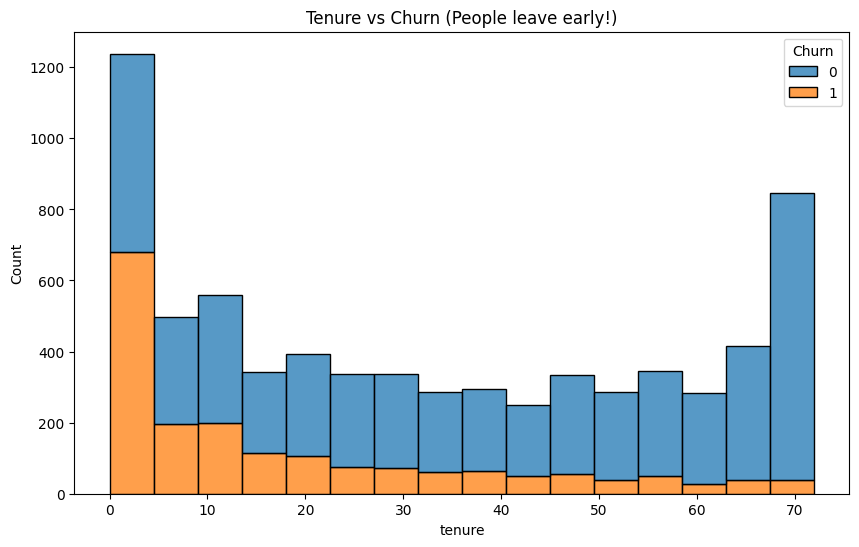

In [6]:
# Visualize Churn vs Tenure
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack')
plt.title('Tenure vs Churn (People leave early!)')
plt.show()

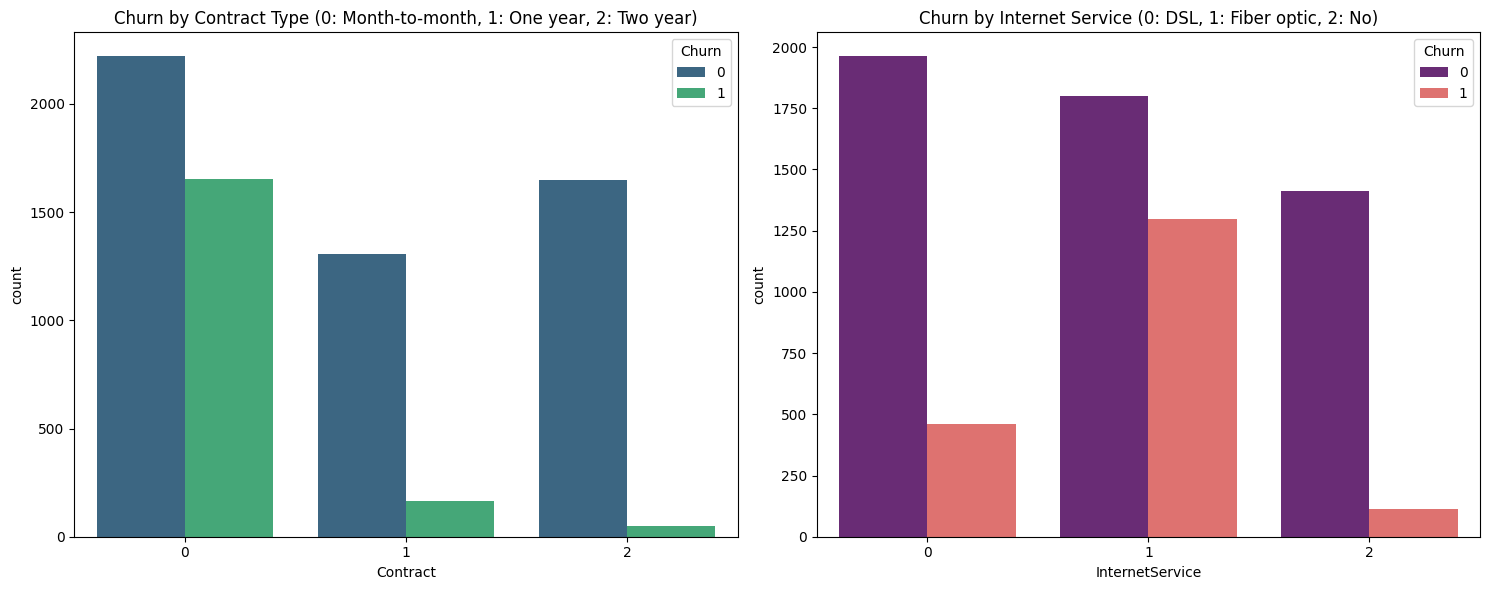

In [7]:
# Create a subplot grid
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Churn by Contract Type
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0], palette='viridis')
axes[0].set_title('Churn by Contract Type (0: Month-to-month, 1: One year, 2: Two year)')

# 2. Churn by Internet Service
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[1], palette='magma')
axes[1].set_title('Churn by Internet Service (0: DSL, 1: Fiber optic, 2: No)')

plt.tight_layout()
plt.show()

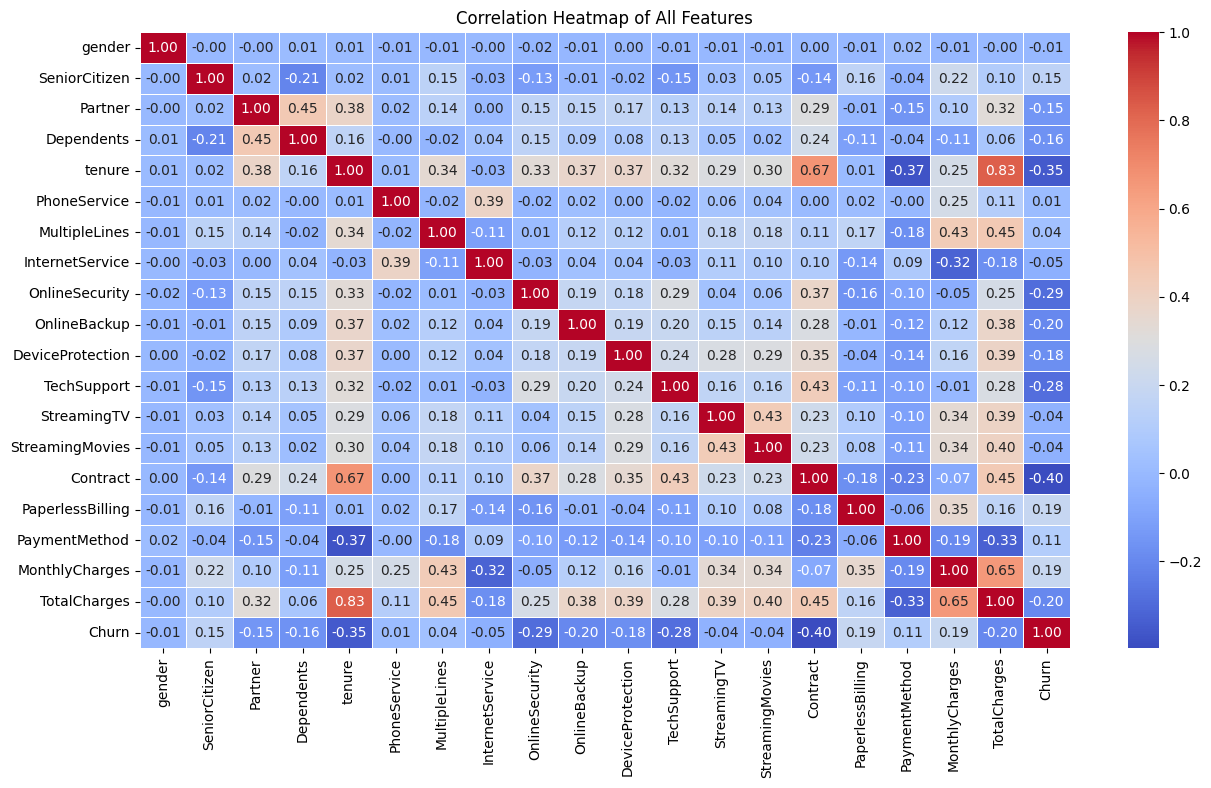

In [8]:
plt.figure(figsize=(15, 8))
# Calculating correlation with the target 'Churn'
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of All Features')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_19232\2538314215.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='Blues_r')


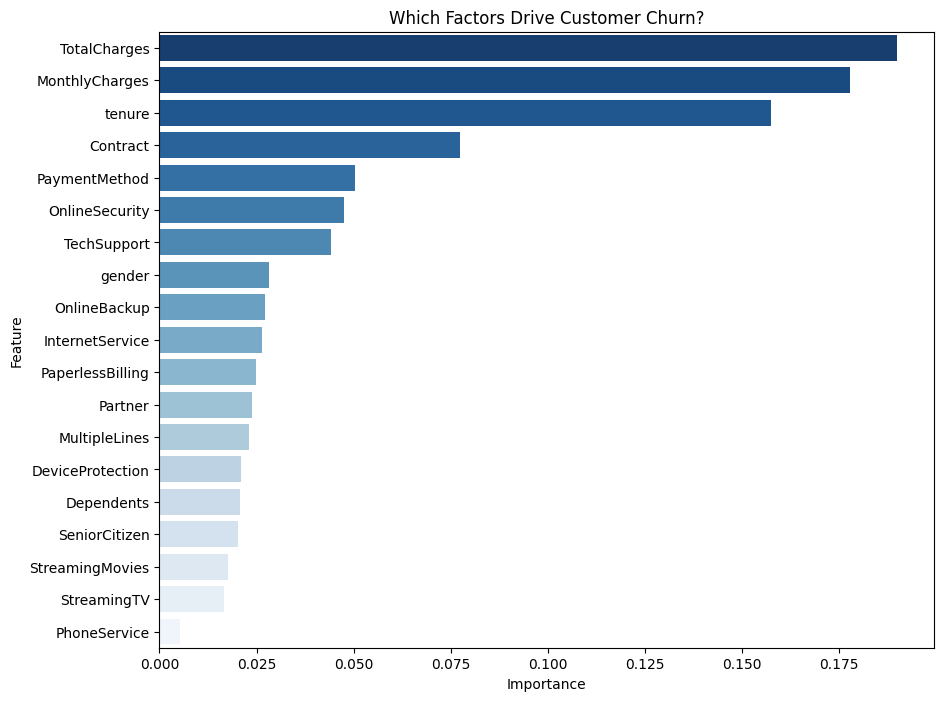

In [9]:
# Get feature importance from the model
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='Blues_r')
plt.title('Which Factors Drive Customer Churn?')
plt.show()

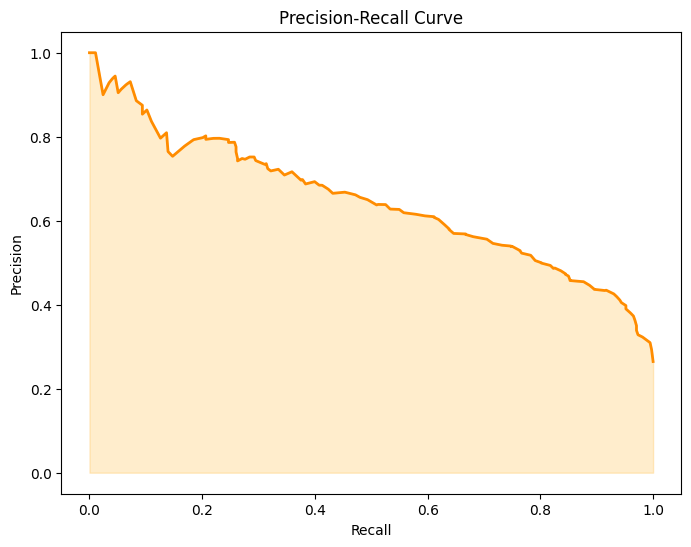

In [10]:
from sklearn.metrics import precision_recall_curve, auc

# Get probabilities for the positive class (Churn)
y_probs = model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.fill_between(recall, precision, alpha=0.2, color='orange')
plt.show()

In [11]:
def check_churn_risk(customer_data):
    # Scale the input just like the training data
    customer_scaled = scaler.transform([customer_data])
    prediction = model.predict(customer_scaled)
    probability = model.predict_proba(customer_scaled)[0][1]
    
    if prediction[0] == 1:
        return f"⚠️ High Risk! Probability of Churn: {probability*100:.2f}%"
    else:
        return f"✅ Safe. Probability of Churn: {probability*100:.2f}%"

# Example: Checking a random row from your test set
sample_customer = X.iloc[0].values
print(check_churn_risk(sample_customer))

✅ Safe. Probability of Churn: 28.00%


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
